# QA/QC of historical runs

Once bias-corrected and downscaled, historical simulations should perform well in high level performance statsitics calculated against the training dataset (in our case, ERA5). They will still not match in more detailed comparisons. This notebook will perform some standard evaluations to understand how a dataset compares against ERA5, as well as another comparison dataset (e.g. a previous version of a downscaled dataset).

Use cases of this notebook:
- you've run the downscaling code and want to see how the results compare to ERA5
- you've run a new version of the downscaling code and want to see how the results compare to the earlier version, with the context of the  ERA5 and the raw input GCM

In [168]:
%load_ext autoreload
%autoreload 2
import duckdb
import geopandas as gpd
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterix
import seaborn as sns
import xarray as xr
from ibicus.debias import QuantileMapping
from rasterix.rasterize.rasterio import geometry_clip

from srm import catalog
from srm.utils import icechunk_store_to_dataset, clean_up_dataset, convert_precip_units
from srm.plotting import plot_comparisons

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load in dataset you want to inspect

In [138]:
ds1 = xr.open_dataset('s3://carbonplan-srm/output/v0.2/pr_model_hist_BCSD_nonparametric.nc', engine='h5netcdf')
ds2 = xr.open_dataset('s3://carbonplan-srm/output/v0.2/pr_model_hist_BCSD_parametric.nc', engine='h5netcdf')

## Load in ERA5 and raw GCM for comparison

In [139]:
variables = ['pr']

In [140]:
era5 = icechunk_store_to_dataset("ERA5", catalog)
era5 = clean_up_dataset(era5, "ERA5")[variables]

## Make a plot comparing maps of some high level statistics

In [141]:
# Trim the comparison datasets to the same spatial extent 

In [143]:
gcm = "CESM2-WACCM" # TODO - once dataset name is fixed this should update to CESM2
scenario = "Historical"# "SSP245" # #  # "G6-1.5K"
dataset_name = f"{gcm}-{scenario}-icechunk"
ensemble_member='007'
# TODO: make the training period an attr in the dataset
training_period = slice("1978-01-01", "2014-12-31") 
# this will restrict the domain to the spatial extent of ds1
lon_max, lon_min = ds1.longitude.max().values, ds1.longitude.min().values
lat_max, lat_min = ds1.latitude.max().values, ds1.latitude.min().values

In [144]:
raw = icechunk_store_to_dataset(dataset_name, catalog)

In [145]:
raw = clean_up_dataset(raw, gcm)[variables]

In [147]:
# for this set-up we'll convert precip units to all be on mm/day
ds1 = convert_precip_units(ds1, 'ERA5')
ds1 = ds1.drop('spatial_ref')
if ds2 is not None:
    ds2 = convert_precip_units(ds2, 'ERA5')
    ds2 = ds2.drop('spatial_ref')

/tmp/ipykernel_15749/4216431243.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds1 = ds1.drop('spatial_ref')
/tmp/ipykernel_15749/4216431243.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds2 = ds2.drop('spatial_ref')


### Subset to the training period for an appropriate comparison

In [148]:
variable=variables[0]

In [149]:
raw = raw.sel(time=training_period, 
              latitude=slice(lat_min, lat_max), 
              longitude=slice(lon_min, lon_max))
era5 = era5.sel(time=training_period, 
              latitude=slice(lat_min, lat_max), 
              longitude=slice(lon_min, lon_max))
ds1 = ds1.sel(time=training_period)
ds2 = ds2.sel(time=training_period)

In [151]:
raw_toplot = raw.isel(time=slice(0, 365)).mean(dim='time')[variable].load()
era5_toplot = era5.isel(time=slice(0, 365)).mean(dim='time')[variable].load()
ds1_toplot = ds1.isel(time=slice(0, 365)).mean(dim='time')[variable].load()
ds2_toplot = ds2.isel(time=slice(0, 365)).mean(dim='time')[variable].load()

here


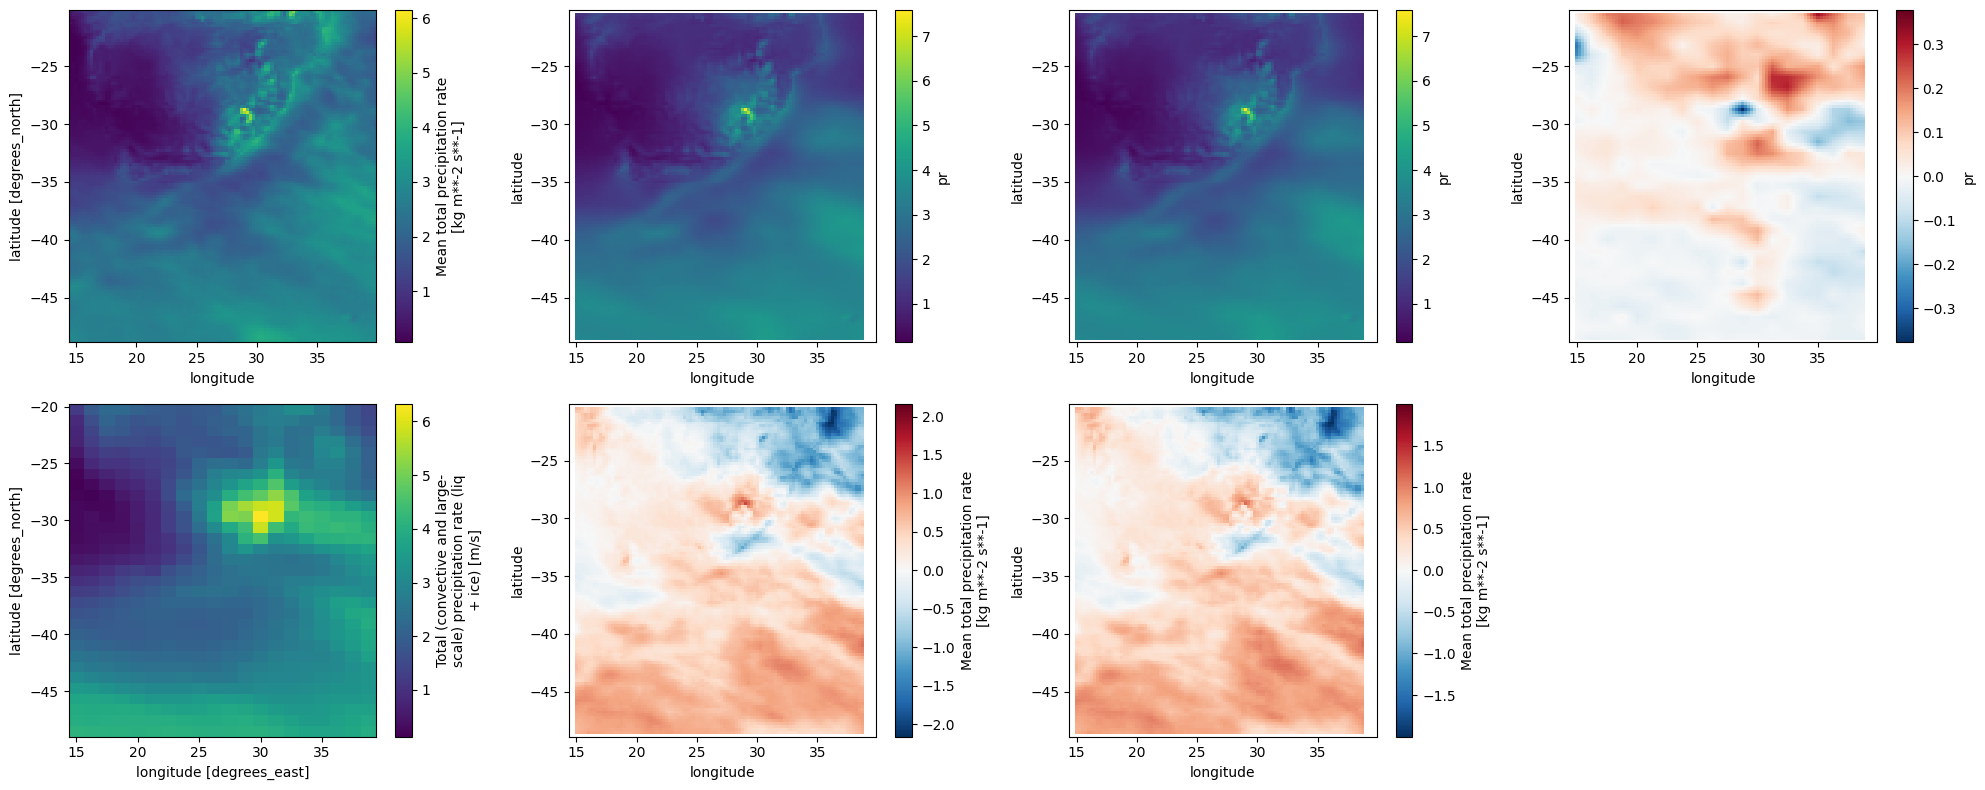

In [170]:
plot_comparisons(era5_toplot, raw_toplot, ds1_toplot, ds2_toplot) 